In [27]:
# 1. LIBRARIES
import os
import csv
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay,
                             f1_score, balanced_accuracy_score)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
print(f"PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()}")

PyTorch 2.4.1+cu124 | CUDA: True


In [28]:
# 2. CONFIGURATION
IMG_SIZE = 224
SEG_SIZE = 320
BATCH_SIZE = 32
NUM_EPOCHS = 30
LR = 1e-4
SEED = 42
CLASS_NAMES = ['MEL', 'NV', 'BCC', 'AK', 'BKL', 'DF', 'VASC', 'SCC']
NUM_CLASSES = len(CLASS_NAMES)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [29]:
# 3. PATHS AND LABELS
IMG_DIR_TRAIN  = "/workspace/datasets/ISIC2019/images/ISIC_2019_Training_Input/ISIC_2019_Training_Input"
IMG_DIR_TEST = "/workspace/datasets/ISIC2019/images/ISIC_2019_Test_Input/ISIC_2019_Test_Input"
CSV_TRAIN = "/workspace/datasets/ISIC2019/labels/ISIC_2019_Training_GroundTruth.csv"
CSV_TEST = "/workspace/datasets/ISIC2019/labels/ISIC_2019_Test_GroundTruth.csv"
UNET_PATH = "/workspace/unet_best.pth"
MASK_DIR_TRAIN = "/workspace/datasets/ISIC2019/masks_train"
MASK_DIR_TEST = "/workspace/datasets/ISIC2019/masks_test"
os.makedirs(MASK_DIR_TRAIN, exist_ok=True)
os.makedirs(MASK_DIR_TEST,  exist_ok=True)

df_train = pd.read_csv(CSV_TRAIN)
df_train = df_train[df_train['UNK'] == 0.0].reset_index(drop=True)
df_train['label']    = df_train[CLASS_NAMES].values.argmax(axis=1)
df_train['filename'] = df_train['image'].apply(lambda x: x + '.jpg')
df_train = df_train[df_train['filename'].apply(
    lambda x: os.path.exists(os.path.join(IMG_DIR_TRAIN, x))
)].reset_index(drop=True)
print(f"Training images found: {len(df_train)}")

df_test = pd.read_csv(CSV_TEST)
df_test = df_test[df_test['UNK'] == 0.0].reset_index(drop=True)
df_test['label']    = df_test[CLASS_NAMES].values.argmax(axis=1)
df_test['filename'] = df_test['image'].apply(lambda x: x + '.jpg')
df_test = df_test[df_test['filename'].apply(
    lambda x: os.path.exists(os.path.join(IMG_DIR_TEST, x))
)].reset_index(drop=True)
print(f"Test images found: {len(df_test)}")

df = df_train

print("\nClass distribution (train):")
for i, cls in enumerate(CLASS_NAMES):
    n = (df_train['label'] == i).sum()
    print(f"  {cls}: {n} ({100*n/len(df_train):.1f}%)")

Training images found: 25331
Test images found: 6191

Class distribution (train):
  MEL: 4522 (17.9%)
  NV: 12875 (50.8%)
  BCC: 3323 (13.1%)
  AK: 867 (3.4%)
  BKL: 2624 (10.4%)
  DF: 239 (0.9%)
  VASC: 253 (1.0%)
  SCC: 628 (2.5%)


In [30]:
# 4. U-NET DEFINITION
import segmentation_models_pytorch as smp
unet = smp.UnetPlusPlus(
    encoder_name="efficientnet-b5",
    encoder_weights=None,
    in_channels=3,
    classes=1,
    activation=None
).to(device)
unet.load_state_dict(torch.load(UNET_PATH, map_location=device, weights_only=True))
unet.eval()
print("U-Net++ loaded successfully")

U-Net++ loaded successfully


In [31]:
# 5. GENERATE MASKS
seg_mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(device)
seg_std  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(device)

def generate_masks(df, img_dir, mask_dir):
    already_done = set(os.listdir(mask_dir))
    to_process   = [f for f in df['filename'].tolist()
                    if f.replace('.jpg', '_mask.png') not in already_done]
    print(f"Generating {len(to_process)} masks in {mask_dir}...")
    MASK_BATCH = 16
    errors = 0
    with torch.no_grad():
        for start in range(0, len(to_process), MASK_BATCH):
            batch_files = to_process[start:start + MASK_BATCH]
            imgs, valid_files = [], []
            for fname in batch_files:
                try:
                    img = Image.open(os.path.join(img_dir, fname)).convert("RGB")
                    img = img.resize((SEG_SIZE, SEG_SIZE), Image.BILINEAR)
                    img_t = torch.tensor(np.array(img)).permute(2,0,1).float() / 255.0
                    imgs.append(img_t)
                    valid_files.append(fname)
                except Exception:
                    errors += 1
            if not imgs:
                continue
            batch_t = torch.stack(imgs).to(device)
            batch_t = (batch_t - seg_mean) / seg_std
            with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                logits = unet(batch_t)
            masks = (torch.sigmoid(logits) > 0.5).squeeze(1).cpu().numpy()
            for fname, mask in zip(valid_files, masks):
                mask_img  = Image.fromarray((mask * 255).astype(np.uint8))
                mask_name = fname.replace('.jpg', '_mask.png')
                mask_img.save(os.path.join(mask_dir, mask_name))
            if (start // MASK_BATCH) % 100 == 0:
                print(f"  {start}/{len(to_process)}")
    print(f"Done. Errors: {errors} | Total masks: {len(os.listdir(mask_dir))}")

generate_masks(df_train, IMG_DIR_TRAIN, MASK_DIR_TRAIN)
generate_masks(df_test,  IMG_DIR_TEST,  MASK_DIR_TEST)


Generating 0 masks in /workspace/datasets/ISIC2019/masks_train...
Done. Errors: 0 | Total masks: 25331
Generating 0 masks in /workspace/datasets/ISIC2019/masks_test...
Done. Errors: 0 | Total masks: 6191


In [32]:
# 6. DATASETS
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.1),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class ISIC2019Original(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        img   = Image.open(os.path.join(self.img_dir,
                           row['filename'])).convert("RGB")
        label = int(row['label'])
        if self.transform:
            img = self.transform(img)
        return img, label, row['filename']

class ISIC2019Masked(Dataset):
    def __init__(self, dataframe, img_dir, mask_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row       = self.df.iloc[idx]
        img       = Image.open(os.path.join(self.img_dir,
                               row['filename'])).convert("RGB")
        mask_name = row['filename'].replace('.jpg', '_mask.png')
        mask_path = os.path.join(self.mask_dir, mask_name)
        if os.path.exists(mask_path):
            mask    = Image.open(mask_path).convert("L")
            mask    = mask.resize(img.size, Image.NEAREST)
            mask_np = np.array(mask) > 127
            img_np  = np.array(img)
            img_np[~mask_np] = 0
            img = Image.fromarray(img_np)
        label = int(row['label'])
        if self.transform:
            img = self.transform(img)
        return img, label, row['filename']

In [33]:
# 7. SPLIT + DATALOADERS
train_df, val_df = train_test_split(
    df_train, test_size=0.15, random_state=SEED, stratify=df_train['label']
)
test_df = df_test  

print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")
print(f"Test  : {len(test_df)}  <- official ISIC 2019 test set")

train_A = ISIC2019Original(train_df, IMG_DIR_TRAIN, train_transform)
val_A   = ISIC2019Original(val_df,   IMG_DIR_TRAIN, val_transform)
test_A  = ISIC2019Original(test_df,  IMG_DIR_TEST,  val_transform)
train_B = ISIC2019Masked(train_df, IMG_DIR_TRAIN, MASK_DIR_TRAIN, train_transform)
val_B   = ISIC2019Masked(val_df,   IMG_DIR_TRAIN, MASK_DIR_TRAIN, val_transform)
test_B  = ISIC2019Masked(test_df,  IMG_DIR_TEST,  MASK_DIR_TEST,  val_transform)

loader_args    = dict(batch_size=BATCH_SIZE, num_workers=4, pin_memory=True)
train_loader_A = DataLoader(train_A, shuffle=True,  **loader_args)
val_loader_A   = DataLoader(val_A,   shuffle=False, **loader_args)
test_loader_A  = DataLoader(test_A,  shuffle=False, **loader_args)
train_loader_B = DataLoader(train_B, shuffle=True,  **loader_args)
val_loader_B   = DataLoader(val_B,   shuffle=False, **loader_args)
test_loader_B  = DataLoader(test_B,  shuffle=False, **loader_args)


Train : 21531
Val   : 3800
Test  : 6191  <- official ISIC 2019 test set


In [34]:
# 8. TRAINING FUNCTION
class_counts  = df_train['label'].value_counts().sort_index().values
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * NUM_CLASSES
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

def build_model():
    m = models.efficientnet_b4(
        weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
    in_features = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, NUM_CLASSES)
    )
    return m.to(device)

def compute_accuracy(outputs, labels):
    return (outputs.argmax(dim=1) == labels).float().mean().item()

def mixup_data(x, y, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1
    index = torch.randperm(x.size(0)).to(device)
    mixed_x = lam * x + (1 - lam) * x[index]
    return mixed_x, y, y[index], lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

def train_model(train_loader, val_loader, model_name, num_epochs=NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"  TRAINING MODEL {model_name}")
    print(f"{'='*60}")
    model   = build_model()
    scaler  = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))
    history = {"epoch": [], "train_loss": [], "train_acc": [],
               "val_loss": [], "val_acc": [], "phase": []}
    best_acc = -1.0
    UNFREEZE = 5
    for param in model.features.parameters():
        param.requires_grad = False
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=3, factor=0.5)
    for epoch in range(1, num_epochs + 1):
        if epoch == UNFREEZE:
            for param in model.features.parameters():
                param.requires_grad = True
            optimizer = optim.Adam(
                model.parameters(), lr=LR/10, weight_decay=1e-4)
            scheduler = optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="max", patience=3, factor=0.5)
            print(f"\n Epoch {epoch}: Thawed Backbone, LR={LR/10:.2e}")
        phase = "frozen" if epoch < UNFREEZE else "finetuning"
        model.train()
        t_loss, t_acc = 0.0, 0.0
        for imgs, labels, _ in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            imgs, labels_a, labels_b, lam = mixup_data(imgs, labels)
            optimizer.zero_grad()
            with torch.amp.autocast("cuda", enabled=(device.type=="cuda")):
                out  = model(imgs)
                loss = mixup_criterion(criterion, out, labels_a, labels_b, lam)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            t_loss += loss.item()
            t_acc  += compute_accuracy(out, labels_a)
        t_loss /= len(train_loader)
        t_acc  /= len(train_loader)
        model.eval()
        v_loss, v_acc = 0.0, 0.0
        with torch.no_grad():
            for imgs, labels, _ in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                with torch.amp.autocast("cuda", enabled=(device.type=="cuda")):
                    out  = model(imgs)
                    loss = criterion(out, labels)
                v_loss += loss.item()
                v_acc  += compute_accuracy(out, labels)
        v_loss /= len(val_loader)
        v_acc  /= len(val_loader)
        scheduler.step(v_acc)
        lr_now = optimizer.param_groups[0]["lr"]
        if v_acc > best_acc:
            best_acc = v_acc
            torch.save(model.state_dict(),
                       f"efficientnet_{model_name}.pth")
        history["epoch"].append(epoch)
        history["train_loss"].append(t_loss)
        history["train_acc"].append(t_acc)
        history["val_loss"].append(v_loss)
        history["val_acc"].append(v_acc)
        history["phase"].append(phase)
        print(f"[{epoch:02d}/{num_epochs}] "
              f"loss:{t_loss:.4f} acc:{t_acc:.4f} | "
              f"val_loss:{v_loss:.4f} val_acc:{v_acc:.4f} | "
              f"LR:{lr_now:.2e} | {phase}")
    print(f"\n Best Val Acc [{model_name}]: {best_acc:.4f}")
    with open(f"history_{model_name}.csv", "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=history.keys())
        writer.writeheader()
        for row in zip(*history.values()):
            writer.writerow(dict(zip(history.keys(), row)))
    return model, history, best_acc



In [35]:
# 9. TRAIN MODEL A — Original Image
model_A, history_A, best_acc_A = train_model(
    train_loader_A, val_loader_A, model_name="A_original"
)


  TRAINING MODEL A_original
[01/30] loss:2.8851 acc:0.0510 | val_loss:2.8367 val_acc:0.0931 | LR:1.00e-04 | frozen
[02/30] loss:2.8014 acc:0.0741 | val_loss:2.7730 val_acc:0.1939 | LR:1.00e-04 | frozen
[03/30] loss:2.7644 acc:0.1142 | val_loss:2.7343 val_acc:0.2403 | LR:1.00e-04 | frozen
[04/30] loss:2.7433 acc:0.1302 | val_loss:2.7091 val_acc:0.2471 | LR:1.00e-04 | frozen

 Epoch 5: Thawed Backbone, LR=1.00e-05
[05/30] loss:2.7150 acc:0.1403 | val_loss:2.6576 val_acc:0.2754 | LR:1.00e-05 | finetuning
[06/30] loss:2.6846 acc:0.1527 | val_loss:2.6199 val_acc:0.3375 | LR:1.00e-05 | finetuning
[07/30] loss:2.6567 acc:0.1626 | val_loss:2.5962 val_acc:0.3516 | LR:1.00e-05 | finetuning
[08/30] loss:2.6502 acc:0.1829 | val_loss:2.5689 val_acc:0.3905 | LR:1.00e-05 | finetuning
[09/30] loss:2.6254 acc:0.1925 | val_loss:2.5523 val_acc:0.3621 | LR:1.00e-05 | finetuning
[10/30] loss:2.6127 acc:0.1931 | val_loss:2.5208 val_acc:0.3805 | LR:1.00e-05 | finetuning
[11/30] loss:2.6162 acc:0.1974 | val_

In [36]:
# 10. TRAIN MODEL B — Masked Image
model_B, history_B, best_acc_B = train_model(
    train_loader_B, val_loader_B, model_name="B_masked"
)



  TRAINING MODEL B_masked
[01/30] loss:2.8798 acc:0.0430 | val_loss:2.8486 val_acc:0.1145 | LR:1.00e-04 | frozen
[02/30] loss:2.8058 acc:0.0683 | val_loss:2.7903 val_acc:0.1444 | LR:1.00e-04 | frozen
[03/30] loss:2.7879 acc:0.0958 | val_loss:2.7588 val_acc:0.1826 | LR:1.00e-04 | frozen
[04/30] loss:2.7518 acc:0.1169 | val_loss:2.7216 val_acc:0.1922 | LR:1.00e-04 | frozen

 Epoch 5: Thawed Backbone, LR=1.00e-05
[05/30] loss:2.7382 acc:0.1384 | val_loss:2.6828 val_acc:0.2511 | LR:1.00e-05 | finetuning
[06/30] loss:2.7016 acc:0.1457 | val_loss:2.6580 val_acc:0.2622 | LR:1.00e-05 | finetuning
[07/30] loss:2.6913 acc:0.1626 | val_loss:2.6221 val_acc:0.3006 | LR:1.00e-05 | finetuning
[08/30] loss:2.6603 acc:0.1829 | val_loss:2.6055 val_acc:0.3286 | LR:1.00e-05 | finetuning
[09/30] loss:2.6528 acc:0.1829 | val_loss:2.5891 val_acc:0.3264 | LR:1.00e-05 | finetuning
[10/30] loss:2.6497 acc:0.1847 | val_loss:2.5667 val_acc:0.3547 | LR:1.00e-05 | finetuning
[11/30] loss:2.6375 acc:0.2014 | val_lo

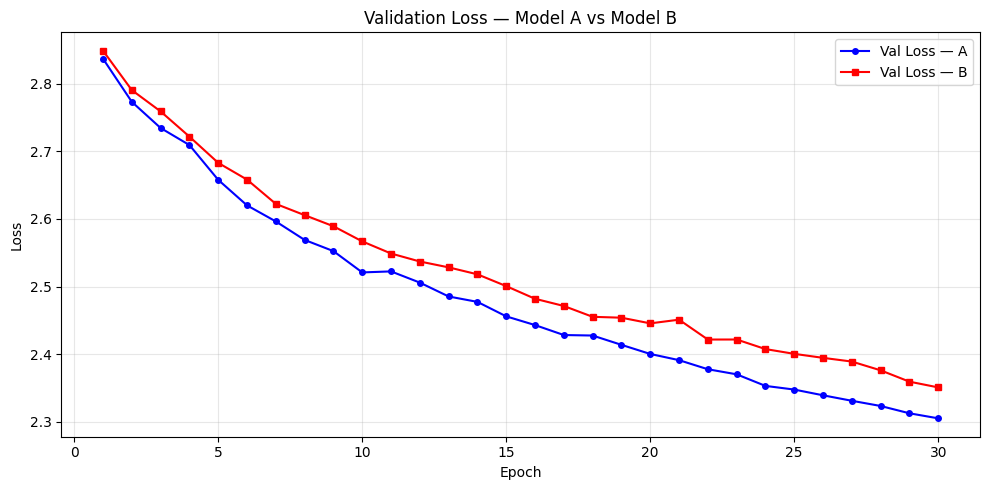

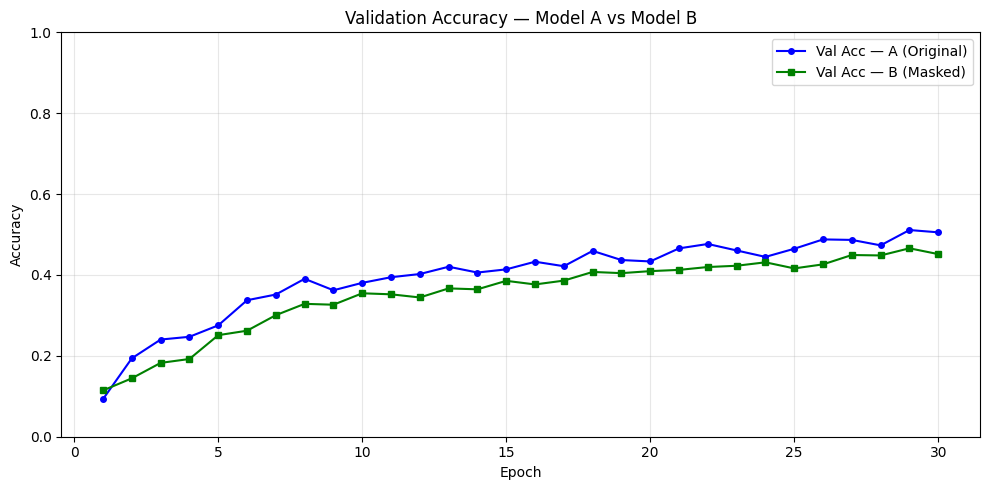

In [37]:
# 11. COMPARATIVE LEARNING CURVES
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_A["epoch"], history_A["val_loss"], "b-o", markersize=4, label="Val Loss — A")
ax.plot(history_B["epoch"], history_B["val_loss"], "r-s", markersize=4, label="Val Loss — B")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Validation Loss — Model A vs Model B")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("learning_curve_loss_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history_A["epoch"], history_A["val_acc"], "b-o", markersize=4, label="Val Acc — A (Original)")
ax.plot(history_B["epoch"], history_B["val_acc"], "g-s", markersize=4, label="Val Acc — B (Masked)")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_title("Validation Accuracy — Model A vs Model B")
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("learning_curve_acc_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


In [38]:
# 12. FINAL EVALUATION — TEST SET
def evaluate_model(model, test_loader, model_name):
    model.load_state_dict(torch.load(
        f"efficientnet_{model_name}.pth",
        map_location=device, weights_only=True))
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels, _ in test_loader:
            imgs = imgs.to(device)
            with torch.amp.autocast("cuda", enabled=(device.type=="cuda")):
                out = model(imgs)
            probs = torch.softmax(out, dim=1).cpu().numpy()
            preds = out.argmax(dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs  = np.array(all_probs)
    acc     = (all_preds == all_labels).mean()
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    try:
        probs_norm = all_probs.astype(np.float64)
        probs_norm = probs_norm / probs_norm.sum(axis=1, keepdims=True)
        auc = roc_auc_score(all_labels, probs_norm,
                            multi_class="ovr", average="macro")
    except Exception as e:
        print(f"AUC error: {e}")
        auc = float("nan")
    print(f"\n{'='*60}")
    print(f"  MODEL {model_name} — TEST SET RESULTS")
    print(f"{'='*60}")
    print(f"  Accuracy          : {acc:.4f}")
    print(f"  Balanced Accuracy : {bal_acc:.4f}")
    print(f"  Macro AUC         : {auc:.4f}")
    print(f"\n{classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)}")
    return all_preds, all_labels, all_probs, acc, bal_acc, auc

preds_A, labels_A, probs_A, acc_A, bal_acc_A, auc_A = evaluate_model(
    model_A, test_loader_A, "A_original")
preds_B, labels_B, probs_B, acc_B, bal_acc_B, auc_B = evaluate_model(
    model_B, test_loader_B, "B_masked")


  MODEL A_original — TEST SET RESULTS
  Accuracy          : 0.4663
  Balanced Accuracy : 0.5569
  Macro AUC         : 0.8866

              precision    recall  f1-score   support

         MEL     0.6947    0.4732    0.5630      1327
          NV     0.9252    0.4116    0.5698      2495
         BCC     0.6728    0.5210    0.5873       975
          AK     0.3029    0.6043    0.4036       374
         BKL     0.3882    0.4076    0.3976       660
          DF     0.0805    0.7912    0.1462        91
        VASC     0.1079    0.7981    0.1901       104
         SCC     0.2313    0.4485    0.3052       165

    accuracy                         0.4663      6191
   macro avg     0.4254    0.5569    0.3953      6191
weighted avg     0.6966    0.4663    0.5230      6191


  MODEL B_masked — TEST SET RESULTS
  Accuracy          : 0.4463
  Balanced Accuracy : 0.5279
  Macro AUC         : 0.8694

              precision    recall  f1-score   support

         MEL     0.7361    0.4582    0.564

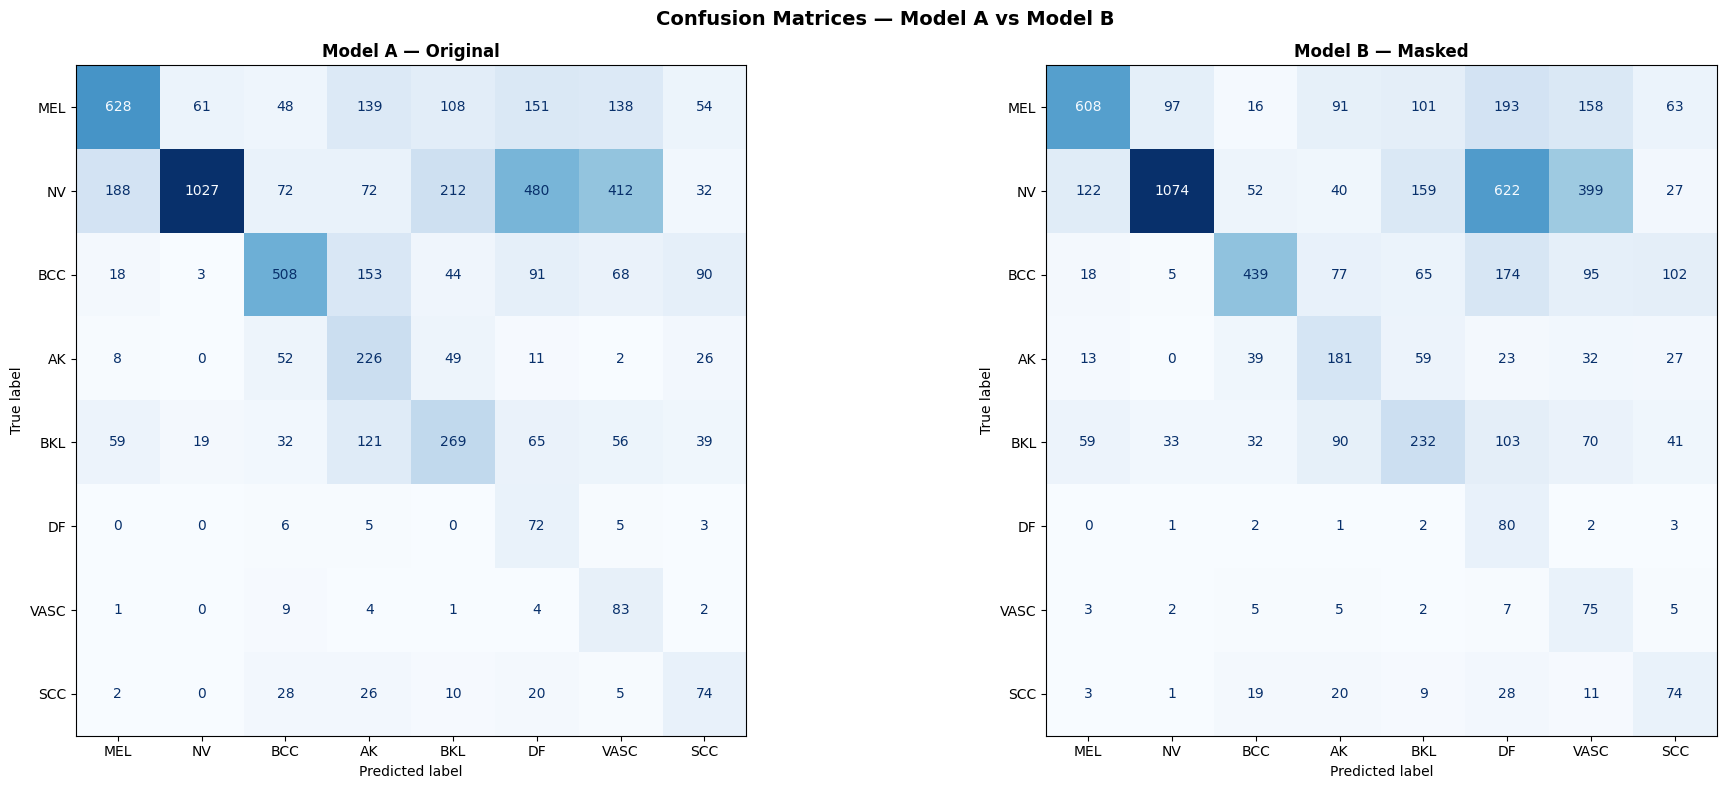

Saved: confusion_matrices.png


In [39]:
# 13. CONFUSION MATRICES
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("Confusion Matrices — Model A vs Model B",
             fontsize=14, fontweight="bold")
for ax, preds, labels, title in zip(
    axes,
    [preds_A, preds_B],
    [labels_A, labels_B],
    ["Model A — Original", "Model B — Masked"]
):
    cm   = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(title, fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")

In [40]:
# 14. FINAL COMPARISON TABLE
f1_A = f1_score(labels_A, preds_A, average="macro")
f1_B = f1_score(labels_B, preds_B, average="macro")
print("\n" + "="*62)
print("  FINAL COMPARISON — Model A vs Model B")
print("="*62)
print(f"  {'Metric':<22} {'Model A (Original)':>18} {'Model B (Masked)':>16}")
print("-"*62)
print(f"  {'Accuracy':<22} {acc_A:>18.4f} {acc_B:>16.4f}")
print(f"  {'Balanced Accuracy':<22} {bal_acc_A:>18.4f} {bal_acc_B:>16.4f}")
print(f"  {'Macro F1':<22} {f1_A:>18.4f} {f1_B:>16.4f}")
print(f"  {'Macro AUC-ROC':<22} {auc_A:>18.4f} {auc_B:>16.4f}")
print("="*62)
with open("comparison_results.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["metric", "model_A_original", "model_B_masked"])
    writer.writerow(["accuracy",          f"{acc_A:.6f}",     f"{acc_B:.6f}"])
    writer.writerow(["balanced_accuracy", f"{bal_acc_A:.6f}", f"{bal_acc_B:.6f}"])
    writer.writerow(["macro_f1",          f"{f1_A:.6f}",      f"{f1_B:.6f}"])
    writer.writerow(["macro_auc",         f"{auc_A:.6f}",     f"{auc_B:.6f}"])
print("Saved: comparison_results.csv")


  FINAL COMPARISON — Model A vs Model B
  Metric                 Model A (Original) Model B (Masked)
--------------------------------------------------------------
  Accuracy                           0.4663           0.4463
  Balanced Accuracy                  0.5569           0.5279
  Macro F1                           0.3953           0.3804
  Macro AUC-ROC                      0.8866           0.8694
Saved: comparison_results.csv


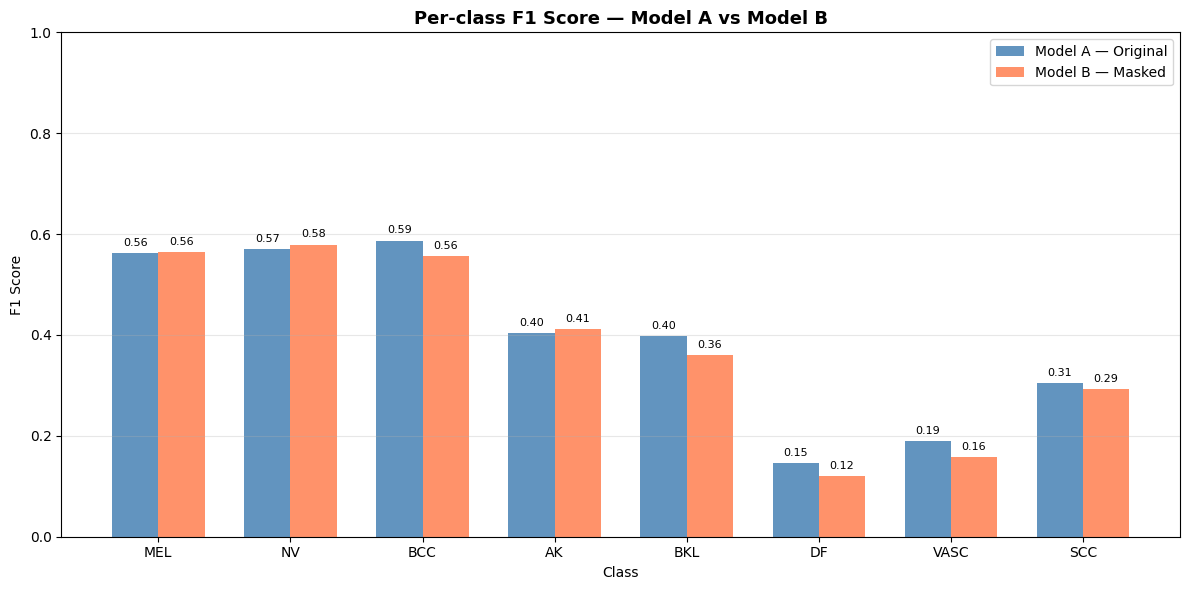

Saved: perclass_f1_comparison.png


In [41]:
# 15. PER-CLASS F1 COMPARISON
f1_A_per = f1_score(labels_A, preds_A, average=None)
f1_B_per = f1_score(labels_B, preds_B, average=None)
x     = np.arange(NUM_CLASSES)
width = 0.35
fig, ax = plt.subplots(figsize=(12, 6))
bars_A = ax.bar(x - width/2, f1_A_per, width,
                label="Model A — Original", color="steelblue", alpha=0.85)
bars_B = ax.bar(x + width/2, f1_B_per, width,
                label="Model B — Masked",   color="coral",     alpha=0.85)
ax.set_xlabel("Class"); ax.set_ylabel("F1 Score")
ax.set_title("Per-class F1 Score — Model A vs Model B",
             fontsize=13, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES)
ax.set_ylim(0, 1); ax.legend(); ax.grid(True, alpha=0.3, axis="y")
for bar in bars_A:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
for bar in bars_B:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("perclass_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: perclass_f1_comparison.png")


In [45]:
# 16. DOWNLOAD ALL RESULTS
import shutil
folder = "TFG_Classification_Results_2"
os.makedirs(folder, exist_ok=True)
files = [
    "efficientnet_A_original.pth",
    "efficientnet_B_masked.pth",
    "history_A_original.csv",
    "history_B_masked.csv",
    "comparison_results.csv",
    "learning_curve_loss_comparison.png",
    "learning_curve_acc_comparison.png",
    "confusion_matrices.png",
    "perclass_f1_comparison.png",
]
for f in files:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(folder, f))
        print(f"✓ {f}")
    else:
        print(f"✗ {f} no encontrado")
shutil.make_archive("TFG_Classification_Results_2", "zip", folder)
print("\n ZIP created: TFG_Classification_Results_2.zip")

✓ efficientnet_A_original.pth
✓ efficientnet_B_masked.pth
✓ history_A_original.csv
✓ history_B_masked.csv
✓ comparison_results.csv
✓ learning_curve_loss_comparison.png
✓ learning_curve_acc_comparison.png
✓ confusion_matrices.png
✓ perclass_f1_comparison.png

 ZIP created: TFG_Classification_Results_2.zip


In [26]:
probs_A_norm = probs_A.astype(np.float64)
probs_A_norm = probs_A_norm / probs_A_norm.sum(axis=1, keepdims=True)

probs_B_norm = probs_B.astype(np.float64)
probs_B_norm = probs_B_norm / probs_B_norm.sum(axis=1, keepdims=True)

print("Sumas A:", probs_A_norm.sum(axis=1)[:5])
print("Sumas B:", probs_B_norm.sum(axis=1)[:5])

auc_A = roc_auc_score(labels_A, probs_A_norm, multi_class="ovr", average="macro")
auc_B = roc_auc_score(labels_B, probs_B_norm, multi_class="ovr", average="macro")
print(f"AUC Model A: {auc_A:.4f}")
print(f"AUC Model B: {auc_B:.4f}")

Sumas A: [1. 1. 1. 1. 1.]
Sumas B: [1. 1. 1. 1. 1.]
AUC Model A: 0.8696
AUC Model B: 0.8579
